# Machine Vision
## Assignment 3 – Features



## Introduction

In this assignment you will implement the Harris corner detector from scratch. The goal is to understand how local image gradients are used to detect stable interest points. You will compute image gradients using 3x3 Sobel filters, form the second-moment matrix terms using a window function, compute the Harris response map, and finally detect corners using thresholding and non-maximum suppression. Fig. 1 below show the corners detected from a test image along with some intermediate results.

Before you start, it is recommended to study [**Lecture 4**](https://moodle.oulu.fi/mod/page/view.php?id=2209769), especially the section about Harris corners. You may also find the example notebook [**`LocalFeatures.ipynb`**](https://github.com/jtheikkila/mvis/blob/master/jupyter/LocalFeatures.ipynb) useful.

![image.jpg](image.jpg)

Let us start by reading an input image and converting it to grayscale:

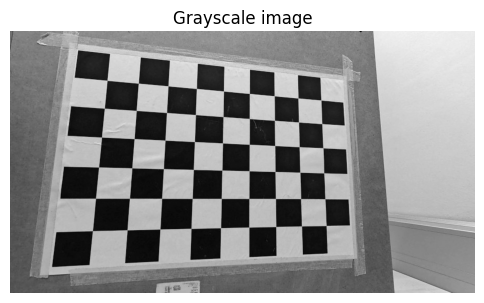

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Load image
img_bgr = cv2.imread("image.jpg", cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
gray = gray.astype(np.float32) / 255.0

plt.figure(figsize=(6, 4))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale image")
plt.axis("off")
plt.show()

## Task 1 – Image gradients <span style="color: red;">(0.5 points)</span>

In this task you will compute the horizontal and vertical image derivatives. These derivatives are the input for the Harris detector, so it is important that they are computed correctly. Use the following 3x3 Sobel kernels:
$$
\mathbf{S}_x = \frac{1}{K}
\begin{bmatrix}
-1 & 0 & 1\\
-2 & 0 & 2\\
-1 & 0 & 1
\end{bmatrix},
\qquad
\mathbf{S}_y = \frac{1}{K}
\begin{bmatrix}
-1 & -2 & -1\\
0 & 0 & 0\\
1 & 2 & 1
\end{bmatrix}.
\tag{1}
$$

The grayscale image `gray` should be filtered with these kernels using [**`cv2.filter2D`**](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#ga27c049795ce870216ddfb366086b5a04) to obtain $I_x$ and $I_y$.

### Instructions
- Define the 3×3 Sobel kernels $\mathbf{S}_x$ and $\mathbf{S}_y$ from Eq. (1). Set $K=8$.
- Compute $I_x$ and $I_y$ using [**`cv2.filter2D`**](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#ga27c049795ce870216ddfb366086b5a04). Set `ddepth=-1` to keep the result as float32.
- The sample notebook [**`Texture.ipynb`**](https://github.com/jtheikkila/mvis/blob/master/jupyter/Texture.ipynb) provides an example of using `cv2.filter2D`.


In [2]:
def image_gradients(gray):
    # Input: 2D float32 grayscale image (H, W)
    # Output: Ix, Iy (float32), same shape as gray

    # ---------- YOUR CODE STARTS HERE -----------
    Sx=(1/8) * np.array([[-1,0,1],
                 [-2,0,2],
                 [-1,0,1],
                 ],dtype=np.float32)

    Sy=(1/8) * np.array([[-1,-2,-1],
                 [0,0,0],
                 [1,2,1],
                 ],dtype=np.float32)

    Ix = cv2.filter2D(gray, -1, Sx)
    Iy = cv2.filter2D(gray, -1, Sy)

    # ----------- YOUR CODE ENDS HERE ------------

    return Ix, Iy


In [ ]:
# LEAVE EMPTY

Run the code below to compute and visualize the image gradients. The result should look the same as in Fig. 1b.

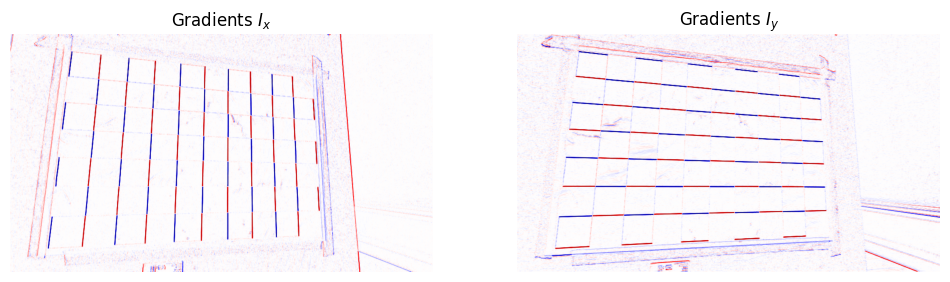

In [3]:
Ix, Iy = image_gradients(gray)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
vmax = np.max(np.abs(Ix))
plt.imshow(Ix, cmap="seismic", vmin=-vmax, vmax=vmax)
plt.title("Gradients $I_x$")
plt.axis("off")

plt.subplot(1, 2, 2)
vmax = np.max(np.abs(Iy))
plt.imshow(Iy, cmap="seismic", vmin=-vmax, vmax=vmax)
plt.title("Gradients $I_y$")
plt.axis("off")
plt.show()

## Task 2 – Corner responses <span style="color: red;">(1.0 point)</span>

In this task you will compute the Harris corner responses $R$ defined as:
$$
R = \det(\mathbf{M}) - \alpha \, \big(\mathrm{trace}(\mathbf{M})\big)^2,
\tag{2}
$$
where $\mathbf{M}$ is the second-moment matrix:
$$
M = \sum_{x,y} w(x,y)
\begin{bmatrix}
I_x^2 & I_x I_y\\
I_x I_y & I_y^2
\end{bmatrix} =
\begin{bmatrix}
A & B\\
B & C
\end{bmatrix}
\tag{3}
$$
The window function $\sum w(x,y)$ represents a local sum over a neighborhood around each pixel. In practise, the terms $A$, $B$, and $C$ can be computed by convolving the gradients with a box kernel (or a Gaussian kernel) $\mathbf{K}$:
$$
A = \mathbf{K} \ast I_x^2, \qquad B = \mathbf{K} \ast I_x I_y, \qquad C = \mathbf{K} \ast I_y^2,
\tag{4}
$$
where $\ast$ denotes convolution. OpenCV provides the function [**`cv2.boxFilter`**](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#gad533230ebf2d42509547d514f7d3fbc3) that implements the box filter. This has the effect of smoothing the gradients that may otherwise be noisy.

After computing the smoothed images $A$, $B$, and $C$, the determinant and trace in Eq.(2) are obtained by:
$$
\det(\mathbf{M}) = AC - B^2, \qquad \mathrm{trace}(\mathbf{M}) = A + C.
\tag{5}
$$

### Instructions
- Given $I_x$ and $I_y$ from Task 1, compute element-wise products $I_x^2$, $I_y^2$, and $I_x I_y$.
- Compute $A$, $B$, and $C$ using [**`cv2.boxFilter`**](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#gad533230ebf2d42509547d514f7d3fbc3) with `ksize=(2,2)` and `normalize=False`. Set `ddepth=-1` to keep the result as float32.
- Compute the corner responses $R$ using Eq.(2) with `alpha=0.04`.

In [4]:
def corner_responses(Ix, Iy, alpha=0.04, ksize=(2, 2)):
    # Input: Ix, Iy gradient images (H, W)
    # Output: Harris response R (float32), same shape.

    # ---------- YOUR CODE STARTS HERE -----------
    Ix2 = Ix**2
    Iy2 = Iy**2
    Ixy = Ix*Iy

    A = cv2.boxFilter(Ix2, ddepth=-1, ksize=(2,2), normalize=False)
    B = cv2.boxFilter(Ixy, ddepth=-1, ksize=(2,2), normalize=False)
    C = cv2.boxFilter(Iy2, ddepth=-1, ksize=(2,2), normalize=False)

    R=(A*C)-(B**2)-(alpha*(A+C)**2)

    # ----------- YOUR CODE ENDS HERE ------------

    return R


In [ ]:
# LEAVE EMPTY

The following code computes and visualizes the corner responses. The response map should correspond Fig. 1c. Large positive values indicate corners (red color), negative values are produced by edges (blue), and values close to zero correspond to flat regions (white).

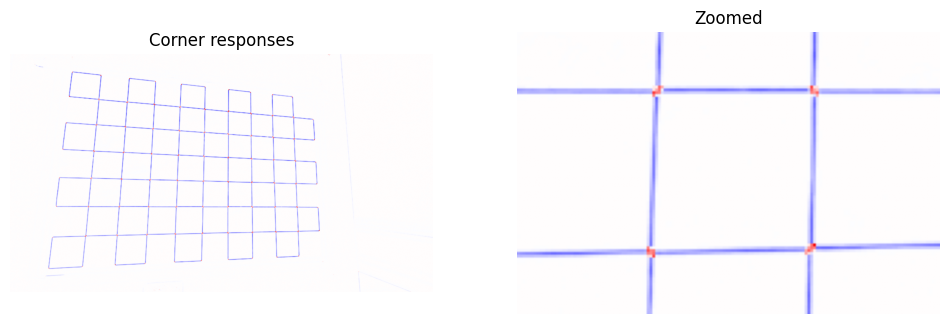

In [5]:
R = corner_responses(Ix, Iy, alpha=0.04, ksize=(2,2))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
vmax = np.max(np.abs(R))
plt.imshow(R, cmap="seismic", vmin=-vmax, vmax=vmax)
plt.title("Corner responses")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(R[300:400, 300:450], cmap="seismic", vmin=-vmax, vmax=vmax)
plt.title("Zoomed")
plt.axis("off")
plt.show()

## Task 3 – Harris corners <span style="color: red;">(0.5 points)</span>

Next, you will detect corners using non-maximum suppression (NMS) and thresholding. Since neighboring pixels can have high responses, this may lead to multiple corner detections clustered around the same location. NMS addresses this by keeping only local maxima, resulting in a set of well-separated, isolated corners. The NMS implementation is provided, and it is based on the reference notebook.

Regarding thresholding, accept only those points with a response at least 20% of the maximum response (similar to [**`LocalFeatures.ipynb`**](https://github.com/jtheikkila/mvis/blob/master/jupyter/LocalFeatures.ipynb)). The detected corners should be the same as in Fig. 1d.

### Instructions
- Perform non-maximum suppression using the provided function `nms(R)`.
- After thresholding, visualize the corners by drawing them on `img_rgb` or `gray` (see [**`LocalFeatures.ipynb`**](https://github.com/jtheikkila/mvis/blob/master/jupyter/LocalFeatures.ipynb)).
- Keep only points where the response is at least 20% of the maximum response.

(np.float64(-0.5), np.float64(888.5), np.float64(499.5), np.float64(-0.5))

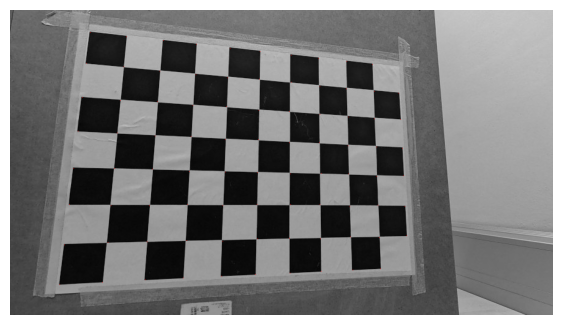

In [6]:
def nms(R):
    R_nms = R.copy()
    R_min = R.min()
    dil = cv2.dilate(R_nms, None, iterations = 3)
    R_nms[R_nms < dil] = R_min
    return R_nms

# ---------- YOUR CODE STARTS HERE -----------
nms=nms(R)

out = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
out[nms>0.2*nms.max()] = [255, 0, 0]

plt.figure(figsize=(7, 10))
plt.subplot(211)
plt.imshow(out)
plt.axis('off')



# ----------- YOUR CODE ENDS HERE ------------